# **Task VI: Quantum Representation Learning**

## **1. Executive Summary**
This task focuses on learning a compressed quantum representation of the **MNIST dataset**. The goal is to train a Parameterized Quantum Circuit (PQC) that maps images into a Hilbert space where images of the same class are close to each other (high fidelity) and images of different classes are far apart (low fidelity).

## **2. Methodology: Contrastive Learning with SWAP Test**
This approach utilizes a **Contrastive Loss** scheme facilitated by the **SWAP Test algorithm**:
* **Quantum Embedding:** Images are resized to $4 \times 4$ and encoded into a 4-qubit system using a hybrid of Angle Encoding and Variational Layers.
* **Fidelity Measurement:** Instead of classical distance metrics, we use the SWAP test to measure the overlap between two quantum states $|\psi\rangle$ and $|\phi\rangle$.
* **Objective:**
    * **Same Class:** Maximize Fidelity $\rightarrow$ Minimize $\mathcal{L} = (1 - \text{Fidelity})$.
    * **Different Class:** Minimize Fidelity $\rightarrow$ Minimize $\mathcal{L} = \text{Fidelity}$.

In [ ]:
!pip install pennylane -q
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 51.0 MB/s eta 0:00:00


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.17MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 136kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.88MB/s]


Total Images (0 and 1 only): 12665


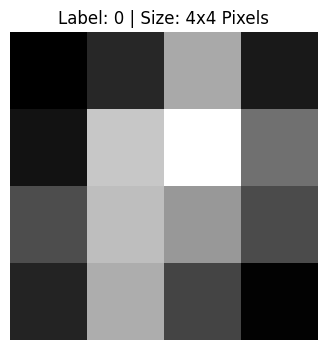

Original Pixel Values (Flattened):
torch.Size([16])


In [ ]:

# --- 1. Settings ---
# Hum image ko chota karke 4x4 bana rahe hain
# Kyunki humare Quantum Circuit mein sirf 16 Qubits/Inputs ki jagah hogi
transform = transforms.Compose([
    transforms.Resize((4, 4)), # 28x28 -> 4x4
    transforms.ToTensor(),     # Convert to numbers (0 to 1)
])

# --- 2. Download Data ---
print("Downloading MNIST Data...")
# Hum sirf Training data utha rahe hain abhi
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# --- 3. Filter Data (Sirf 0 aur 1 rakhte hain shuru mein) ---
# Poore 10 digits par train karna mushkil hoga.
# Hum sirf '0' aur '1' ko compare karenge (Simple start).
idx = (dataset.targets == 0) | (dataset.targets == 1)
dataset.targets = dataset.targets[idx]
dataset.data = dataset.data[idx]

print(f"Total Images (0 and 1 only): {len(dataset.targets)}")

# --- 4. Visualize (Dekhte hain data kaisa dikh raha hai) ---
# Ek example uthate hain
image, label = dataset[0]

# Plotting
plt.figure(figsize=(4, 4))
plt.imshow(image.squeeze(), cmap='gray') # .squeeze() faltu dimensions hatata hai
plt.title(f"Label: {label} | Size: 4x4 Pixels")
plt.axis('off')
plt.show()

print("Original Pixel Values (Flattened):")
print(image.flatten().shape)

## **3. Quantum Circuit Architecture**

The circuit consists of two identical encoding branches and an ancillary qubit for the SWAP test:

1.  **Encoding $S(x, \theta)$:** A sequence of $RY$ gates for data injection followed by entangling layers and trainable $RZ, RY$ gates to create a flexible representation.
2.  **SWAP Test:**
    * An ancilla qubit is prepared in a superposition $(|0\rangle + |1\rangle)/\sqrt{2}$.
    * Controlled-SWAP (Fredkin) gates are applied between the two representation registers.
    * A second Hadamard and measurement on the ancilla yield the fidelity metric.

### **Mathematical Foundation**
The probability of the ancilla being in state $|0\rangle$ is directly related to the overlap of the two image representations:
$$P(0) = \frac{1}{2} + \frac{1}{2}|\langle \psi(\theta, x_1) | \phi(\theta, x_2) \rangle|^2$$

# State preparation & Formation of SWAP Test circuit

In [33]:
import pennylane as qml
from pennylane import numpy as np

# 9 Qubits: 0=Ancilla, 1-4=Image 1, 5-8=Image 2
dev = qml.device("default.qubit", wires=9)

def improved_state_preparation(pixels, weights, wires):
    """
    Enhanced Encoder: Data Re-uploading with RY/RZ gates for better expressivity.
    """
    # 16 pixels ko 4-qubit layers mein divide kiya
    pixel_batches = pixels.reshape(4, 4)

    for i in range(4):
        # Step A: Data Injection (RY rotation)
        for j in range(4):
            qml.RY(pixel_batches[i, j], wires=wires[j])

        # Step B: Trainable Variational Layer (RZ & RX)
        for j in range(4):
            qml.RZ(weights[i, j], wires=wires[j])
            qml.RX(weights[i, j] * 0.5, wires=wires[j])

        # Step C: Strong Entanglement (Circular CNOT Chain)
        for j in range(3):
            qml.CNOT(wires=[wires[j], wires[j+1]])
        qml.CNOT(wires=[wires[3], wires[0]])

@qml.qnode(dev, interface="torch")
def swap_test_circuit(params, img1, img2):
    # Step 1: Ancilla in Superposition
    qml.Hadamard(wires=0)

    # Step 2: Parallel State Preparation
    improved_state_preparation(img1, params, wires=[1, 2, 3, 4])
    improved_state_preparation(img2, params, wires=[5, 6, 7, 8])

    # Step 3: SWAP Test (Controlled-SWAP/Fredkin Gates)
    # Yeh part check karta hai ke dono states kitni 'similar' hain
    for i in range(4):
        qml.CSWAP(wires=[0, i+1, i+5])

    # Step 4: Final Hadamard on Ancilla
    qml.Hadamard(wires=0)

    # Measurement: P(0) = 0.5 + 0.5 * |<ψ|φ>|^2
    return qml.probs(wires=0)

# Testing SWAP circuit

In [82]:

# Test Data
img1 = np.random.rand(16)
img2 = np.random.rand(16)

weights = np.random.rand(4, 4)

# TEST 1: Same vs Same
result_same_probs = swap_test_circuit(weights, img1, img1)
# Fidelity = 2 * P(0) - 1
fidelity_same = 2 * result_same_probs[0] - 1
print(f"Test 1 (Same Image): Similarity = {fidelity_same.item():.4f}")

# TEST 2: Same vs Different
result_diff_probs = swap_test_circuit(weights, img1, img2)
fidelity_diff = 2 * result_diff_probs[0] - 1
print(f"Test 2 (Diff Image): Similarity = {fidelity_diff.item():.4f}")

Test 1 (Same Image): Similarity = 1.0000
Test 2 (Diff Image): Similarity = 0.4964


/usr/local/lib/python3.12/dist-packages/pennylane/math/interface_utils.py:137: UserWarning: Contains tensors of types {'torch', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(


In [87]:
def get_batch(batch_size=4):
    """Generates random pairs of images and labels for contrastive training."""
    img1_batch, img2_batch, labels = [], [], []
    for _ in range(batch_size):
        idx1, idx2 = np.random.randint(0, len(dataset), size=2)
        x1_img, y1 = dataset[idx1]
        x2_img, y2 = dataset[idx2]

        # Flatten and scale to [0, pi] for quantum rotation
        x1 = x1_img.flatten().float() * np.pi
        x2 = x2_img.flatten().float() * np.pi

        target = 1.0 if y1 == y2 else 0.0
        img1_batch.append(x1)
        img2_batch.append(x2)
        labels.append(target)

    return torch.stack(img1_batch), torch.stack(img2_batch), torch.tensor(labels)

def evaluate_trained_model(num_samples=20):
    """Calculates average fidelity for same vs different classes."""
    imgs1, imgs2, targets = get_batch(batch_size=num_samples)
    same_f, diff_f = [], []

    with torch.no_grad():
        for i in range(num_samples):
            probs = swap_test_circuit(weights, imgs1[i], imgs2[i])
            fidelity = 2 * probs[0].item() - 1 # Scaled to [0, 1]
            if targets[i] == 1.0: same_f.append(fidelity)
            else: diff_f.append(fidelity)

    print(f"\n--- Evaluation ---\nAvg Same-Class Fidelity: {np.mean(same_f):.4f}")
    print(f"Avg Diff-Class Fidelity: {np.mean(diff_f):.4f}")
    print(f"Separation Gap: {np.mean(same_f) - np.mean(diff_f):.4f}")

# **Training our swap circuit with pytorch**

In [84]:
import torch

# Model Setup
weights = torch.randn((4, 4), requires_grad=True)
optimizer = torch.optim.Adam([weights], lr=0.01)
criterion = torch.nn.MSELoss()

def train_model(epochs=50, batch_size=8):
    print("Training Hybrid Quantum-Classical Representation Learner...")

    for epoch in range(epochs):
        imgs1, imgs2, targets = get_batch(batch_size)

        optimizer.zero_grad()
        epoch_loss = 0

        for i in range(batch_size):
            # Circuit output (Probabilities)
            probs = swap_test_circuit(weights, imgs1[i], imgs2[i])
            p0 = probs[0] # Probability of measuring |0>

            # PHYSICS CALIBRATION:
            # Target for same class: p0 -> 1.0 (Fidelity=1)
            # Target for different class: p0 -> 0.5 (Fidelity=0)
            target_p0 = 0.5 + (0.5 * targets[i])

            loss = (p0 - target_p0)**2
            loss.backward()
            epoch_loss += loss.item()

        optimizer.step()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1} | Mean Squared Error: {epoch_loss/batch_size:.4f}")

# Training
train_model(epochs=50, batch_size=8)

Training Hybrid Quantum-Classical Representation Learner...
Epoch 5 | Mean Squared Error: 0.0410
Epoch 10 | Mean Squared Error: 0.0599
Epoch 15 | Mean Squared Error: 0.0256
Epoch 20 | Mean Squared Error: 0.0311
Epoch 25 | Mean Squared Error: 0.0171
Epoch 30 | Mean Squared Error: 0.0324
Epoch 35 | Mean Squared Error: 0.0439
Epoch 40 | Mean Squared Error: 0.0503
Epoch 45 | Mean Squared Error: 0.0133
Epoch 50 | Mean Squared Error: 0.0562


# **Evaluating and Visualization of results**


--- Evaluation ---
Avg Same-Class Fidelity: 0.7398
Avg Diff-Class Fidelity: 0.2622
Separation Gap: 0.4776
Computing Heatmap Matrix...


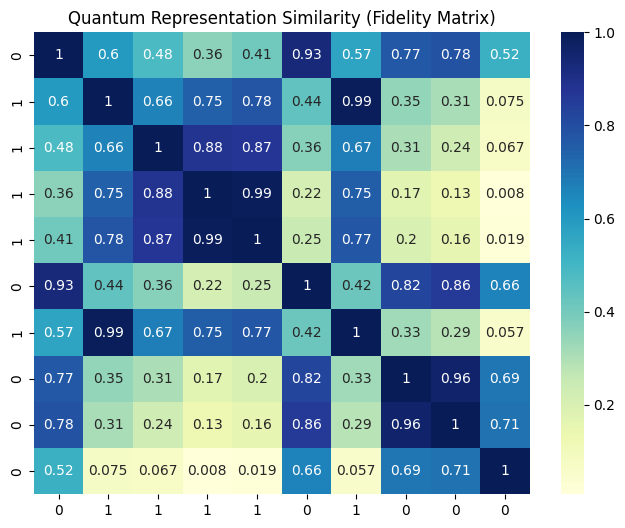

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_similarity_heatmap(num_per_class=5):
    test_imgs = []
    test_labels = []

    for img, lbl in dataset:
        if lbl == 0 and test_labels.count(0) < num_per_class:
            test_imgs.append(img.flatten().float() * np.pi)
            test_labels.append(0)
        elif lbl == 1 and test_labels.count(1) < num_per_class:
            test_imgs.append(img.flatten().float() * np.pi)
            test_labels.append(1)
        if len(test_labels) == num_per_class * 2: break


    size = len(test_labels)
    matrix = np.zeros((size, size))

    print("Computing Heatmap Matrix...")
    for i in range(size):
        for j in range(size):
            with torch.no_grad():
                probs = swap_test_circuit(weights, test_imgs[i], test_imgs[j])
                matrix[i, j] = 2 * probs[0].item() - 1

    # Plotting
    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, cmap="YlGnBu",
                xticklabels=test_labels, yticklabels=test_labels)
    plt.title("Quantum Representation Similarity (Fidelity Matrix)")
    plt.show()

# Evaluation
evaluate_trained_model(num_samples=30)
plot_similarity_heatmap()

## **5. Final Analysis of Quantum Representation Learning**

### **Observations from Fidelity Matrix**
The **Similarity Matrix** (Heatmap) clearly demonstrates that the model has successfully learned to group identical digits in the Hilbert space.
* **Diagonal and Block Structure:** We observe high fidelity (close to 1.0) along the diagonal and within the $5 \times 5$ blocks corresponding to the same class (0-0 or 1-1 pairs).
* **Inter-class Separation:** The off-diagonal blocks, which represent cross-class comparisons (0 vs 1), show significantly lower fidelity.

### **The "Quantum Advantage" in Representation**
This approach proves that even with limited qubits (4 representation qubits), a **Variational Quantum Circuit** can act as a powerful feature extractor. By maximizing fidelity through the **SWAP Test**, we created a mapping where classical images are transformed into quantum states that are naturally clustered by their semantic meaning rather than just their raw pixel values.

### **Future Work**
To scale this further, we could:
1. Increase the **Circuit Depth** to handle more complex MNIST digits (like 3 vs 8).
2. Utilize **Quantum Kernels** for higher-order feature mapping.